In [10]:
# EDA: importar librerias y cargar datos
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("../data/train.csv")

df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [11]:
# EDA: revisar columnas
df.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [12]:
# EDA: resumen de tipos y nulos
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [13]:
# EDA: estadisticas descriptivas
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


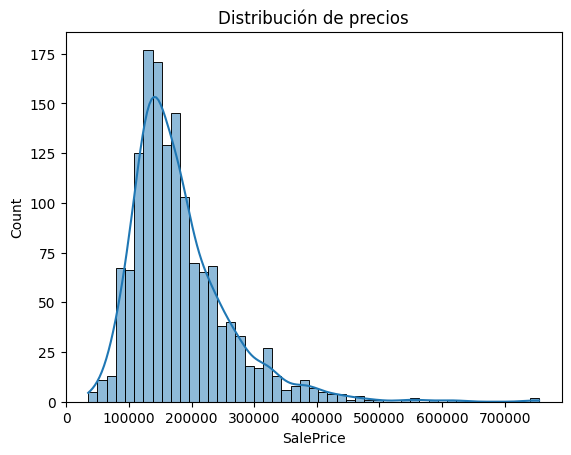

In [14]:
# EDA: distribucion de SalePrice
sns.histplot(df["SalePrice"], kde=True)
plt.title("Distribución de precios")
plt.show()

In [15]:
# EDA: correlacion con SalePrice
corr = df.corr(numeric_only=True)

corr["SalePrice"].sort_values(ascending=False)

SalePrice        1.000000
OverallQual      0.790982
GrLivArea        0.708624
GarageCars       0.640409
GarageArea       0.623431
TotalBsmtSF      0.613581
1stFlrSF         0.605852
FullBath         0.560664
TotRmsAbvGrd     0.533723
YearBuilt        0.522897
YearRemodAdd     0.507101
GarageYrBlt      0.486362
MasVnrArea       0.477493
Fireplaces       0.466929
BsmtFinSF1       0.386420
LotFrontage      0.351799
WoodDeckSF       0.324413
2ndFlrSF         0.319334
OpenPorchSF      0.315856
HalfBath         0.284108
LotArea          0.263843
BsmtFullBath     0.227122
BsmtUnfSF        0.214479
BedroomAbvGr     0.168213
ScreenPorch      0.111447
PoolArea         0.092404
MoSold           0.046432
3SsnPorch        0.044584
BsmtFinSF2      -0.011378
BsmtHalfBath    -0.016844
MiscVal         -0.021190
Id              -0.021917
LowQualFinSF    -0.025606
YrSold          -0.028923
OverallCond     -0.077856
MSSubClass      -0.084284
EnclosedPorch   -0.128578
KitchenAbvGr    -0.135907
Name: SalePr

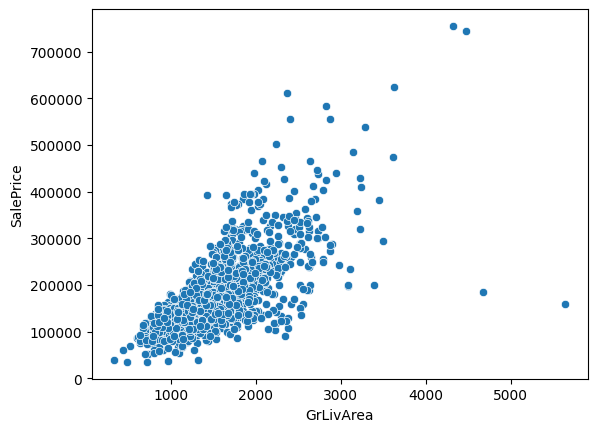

In [16]:
# EDA: relacion GrLivArea vs SalePrice
sns.scatterplot(x="GrLivArea", y="SalePrice", data=df)
plt.show()

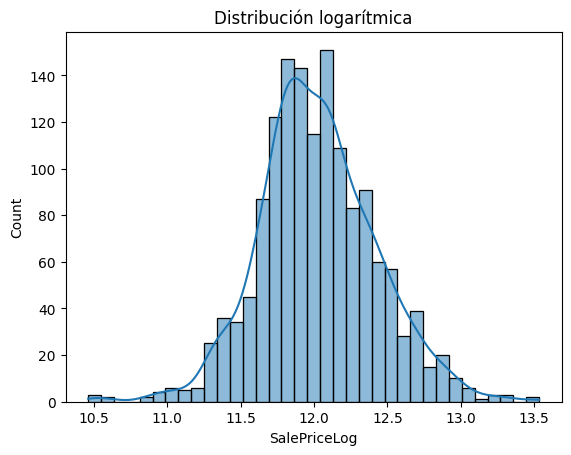

In [17]:
# EDA: transformar SalePrice y ver distribucion
df["SalePriceLog"] = np.log1p(df["SalePrice"])

sns.histplot(df["SalePriceLog"], kde=True)
plt.title("Distribución logarítmica")
plt.show()

<Axes: xlabel='SalePrice'>

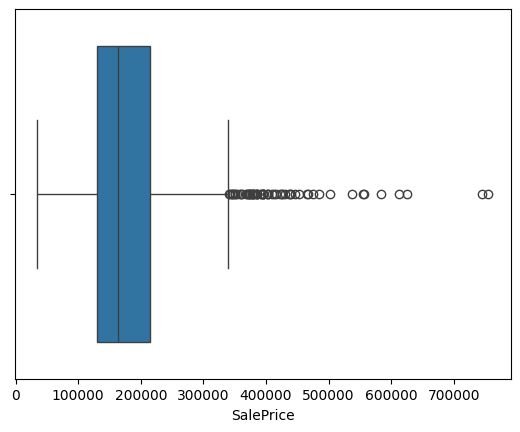

In [18]:
# EDA: detectar outliers en SalePrice
sns.boxplot(x=df["SalePrice"])

In [19]:
# EDA: revisar valores nulos
nulls = df.isnull().sum().sort_values(ascending=False)
nulls = nulls[nulls > 0]

print(nulls)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageQual        81
GarageYrBlt       81
GarageFinish      81
GarageType        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtFinType1      37
BsmtCond          37
MasVnrArea         8
Electrical         1
dtype: int64


In [20]:
# Limpieza: eliminar columnas con muchos nulos
cols_drop = ["PoolQC", "MiscFeature", "Alley", "Fence"]

df.drop(columns=cols_drop, inplace=True)

In [21]:
# Limpieza: imputar valores faltantes
df["FireplaceQu"] = df["FireplaceQu"].fillna("None")
garage_cols = [
    "GarageQual",
    "GarageType",
    "GarageCond",
    "GarageFinish"
]

for col in garage_cols:
    df[col] = df[col].fillna("None")

df["GarageYrBlt"] = df["GarageYrBlt"].fillna(0)
bsmt_cols = [
    "BsmtExposure",
    "BsmtFinType2",
    "BsmtQual",
    "BsmtFinType1",
    "BsmtCond"
]

for col in bsmt_cols:
    df[col] = df[col].fillna("None")

df["LotFrontage"] = df["LotFrontage"].fillna(
    df["LotFrontage"].median()
)

df["MasVnrArea"] = df["MasVnrArea"].fillna(
    df["MasVnrArea"].median()
)

df["MasVnrType"] = df["MasVnrType"].fillna(
    df["MasVnrType"].mode()[0]
)

df["Electrical"] = df["Electrical"].fillna(
    df["Electrical"].mode()[0]
)

df.isnull().sum().sum()

np.int64(0)

In [22]:
# Limpieza: porcentaje de nulos por columna
null_percent = (df.isnull().sum() / len(df)) * 100
null_percent.sort_values(ascending=False)

print(null_percent)

Id               0.0
MSSubClass       0.0
MSZoning         0.0
LotFrontage      0.0
LotArea          0.0
                ... 
YrSold           0.0
SaleType         0.0
SaleCondition    0.0
SalePrice        0.0
SalePriceLog     0.0
Length: 78, dtype: float64


In [23]:
# Preparacion: codificar categoricas y separar X/y
df_encoded = pd.get_dummies(df, drop_first=True)
X = df_encoded.drop(
    ["SalePrice", "SalePriceLog"],
    axis=1
)

y = df_encoded["SalePrice"]

In [24]:
# Preparacion: dividir train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [25]:
# Preparacion: escalar variables numericas


scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [26]:
# Preparacion: inspeccionar columnas codificadas
print(df_encoded.columns)
print(df.columns)
print(df_encoded.columns)

Index(['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual',
       'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1',
       ...
       'SaleType_ConLI', 'SaleType_ConLw', 'SaleType_New', 'SaleType_Oth',
       'SaleType_WD', 'SaleCondition_AdjLand', 'SaleCondition_Alloca',
       'SaleCondition_Family', 'SaleCondition_Normal',
       'SaleCondition_Partial'],
      dtype='str', length=248)
Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope',
       'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle',
       'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle',
       'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea',
       'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond',
       'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heatin

In [27]:
# Preparacion: comparar dimensiones antes/despues
df_encoded = pd.get_dummies(df, drop_first=True)

print("Antes:", df.shape)
print("Después:", df_encoded.shape)

Antes: (1460, 78)
Después: (1460, 248)


In [28]:
# Preparacion: escalar conjuntos para regresion lineal
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [29]:
# Modelado: entrenar regresion lineal
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [30]:
# Modelado: predecir con regresion lineal
y_pred = model.predict(X_test_scaled)

In [31]:
# Evaluacion: metricas regresion lineal
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import r2_score

mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)


MAE: 20607.582950179425
RMSE: 52614.10958804084
R²: 0.6390968971895205


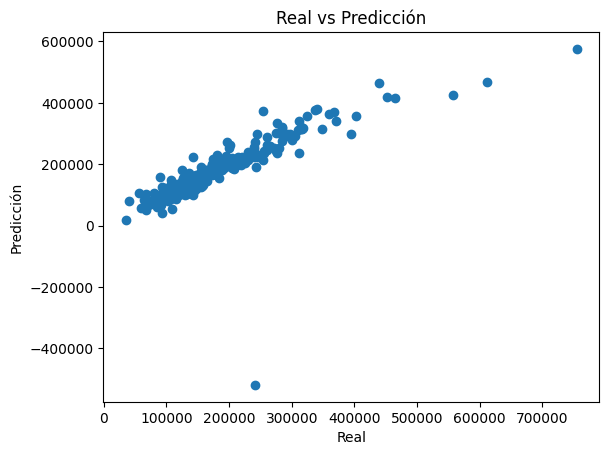

In [32]:
# Evaluacion: grafico real vs prediccion (LR)
plt.scatter(y_test, y_pred)
plt.xlabel("Real")
plt.ylabel("Predicción")
plt.title("Real vs Predicción")
plt.show()

In [33]:
# Evaluacion: comparar predicciones (LR)
comparison = pd.DataFrame({
    "Real": y_test,
    "Prediccion": y_pred
})

print(comparison.head(20))

        Real     Prediccion
892   154500  155967.863915
1105  325000  355991.412999
413   115000   86955.877918
522   159000  179275.374584
1036  315500  321847.020665
614    75500   71287.009873
218   311500  237194.240332
1160  146000  147031.702469
649    84500   61944.364504
887   135500  147073.500189
576   145000  144065.973404
1252  130000  101002.860661
1061   81000   80207.798780
567   214000  220702.555996
1108  181000  174988.330861
1113  134500  130843.887387
168   183500  185329.247920
1102  135000  134640.728678
1120  118400  128993.233693
67    226000  216008.216429


In [34]:
# Evaluacion: calcular error (LR)
comparison["Error"] = comparison["Real"] - comparison["Prediccion"]

print(comparison.head(20))

        Real     Prediccion         Error
892   154500  155967.863915  -1467.863915
1105  325000  355991.412999 -30991.412999
413   115000   86955.877918  28044.122082
522   159000  179275.374584 -20275.374584
1036  315500  321847.020665  -6347.020665
614    75500   71287.009873   4212.990127
218   311500  237194.240332  74305.759668
1160  146000  147031.702469  -1031.702469
649    84500   61944.364504  22555.635496
887   135500  147073.500189 -11573.500189
576   145000  144065.973404    934.026596
1252  130000  101002.860661  28997.139339
1061   81000   80207.798780    792.201220
567   214000  220702.555996  -6702.555996
1108  181000  174988.330861   6011.669139
1113  134500  130843.887387   3656.112613
168   183500  185329.247920  -1829.247920
1102  135000  134640.728678    359.271322
1120  118400  128993.233693 -10593.233693
67    226000  216008.216429   9991.783571


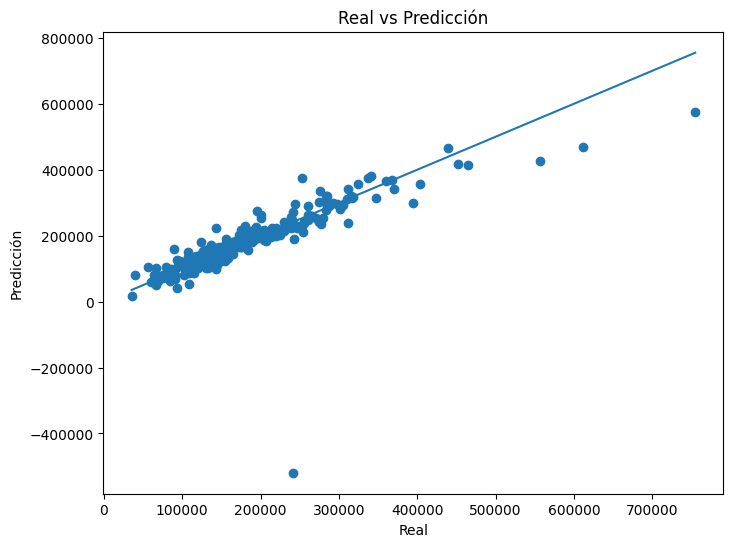

In [35]:
# Evaluacion: diagnostico real vs prediccion (LR)
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

plt.xlabel("Real")
plt.ylabel("Predicción")
plt.title("Real vs Predicción")

plt.show()

In [36]:
# Modelado: entrenar random forest
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [37]:
# Modelado: predecir con random forest
rf_pred = rf_model.predict(X_test)

In [38]:
# Evaluacion: metricas random forest
from sklearn.metrics import (
    mean_absolute_error,
    root_mean_squared_error,
    r2_score
)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = root_mean_squared_error(y_test, rf_pred)
rf_r2 = r2_score(y_test, rf_pred)

print("MAE:", rf_mae)
print("RMSE:", rf_rmse)
print("R²:", rf_r2)

comparison_rf = pd.DataFrame({
    "Real": y_test,
    "Prediccion_RF": rf_pred
})
comparison_rf["Error_RF"] = comparison_rf["Real"] - comparison_rf["Prediccion_RF"]
print(comparison_rf.head(20))

MAE: 17816.28099315069
RMSE: 29412.833128873735
R²: 0.8872127821817596
        Real  Prediccion_RF   Error_RF
892   154500      141066.25   13433.75
1105  325000      320734.44    4265.56
413   115000      117105.00   -2105.00
522   159000      154589.00    4411.00
1036  315500      325066.67   -9566.67
614    75500       82730.75   -7230.75
218   311500      209972.84  101527.16
1160  146000      149217.00   -3217.00
649    84500       83649.66     850.34
887   135500      132389.37    3110.63
576   145000      155052.52  -10052.52
1252  130000      121501.50    8498.50
1061   81000      113273.00  -32273.00
567   214000      206490.07    7509.93
1108  181000      178877.40    2122.60
1113  134500      131926.25    2573.75
168   183500      194627.48  -11127.48
1102  135000      136180.25   -1180.25
1120  118400      113592.00    4808.00
67    226000      206422.20   19577.80


In [39]:
# Evaluacion: importancia de variables (RF)
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

print(importance.head(10))

        Feature  Importance
4   OverallQual    0.559389
16    GrLivArea    0.121035
14     2ndFlrSF    0.035108
12  TotalBsmtSF    0.034127
9    BsmtFinSF1    0.029384
13     1stFlrSF    0.026776
3       LotArea    0.017382
27   GarageArea    0.015495
26   GarageCars    0.012695
6     YearBuilt    0.012543


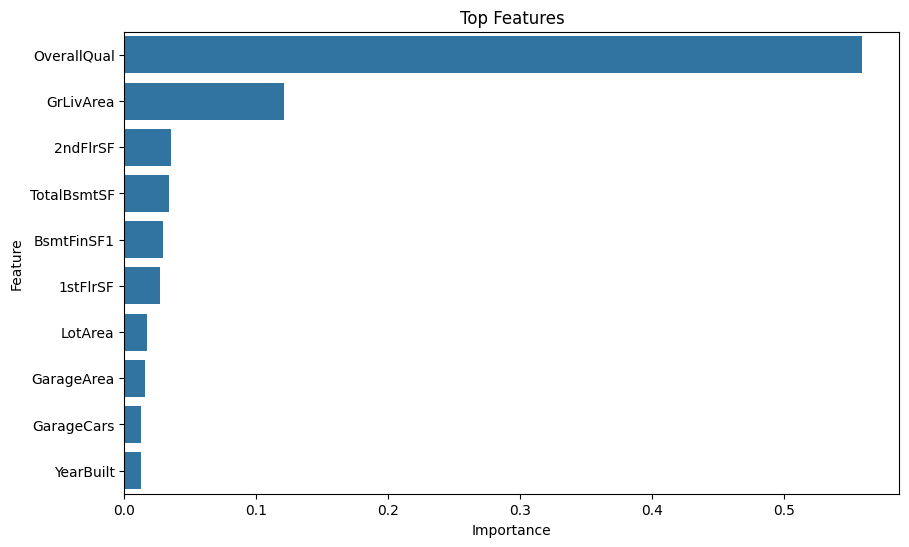

In [40]:
# Evaluacion: visualizar top features (RF)
top10 = importance.head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=top10
)

plt.title("Top Features")

plt.show()

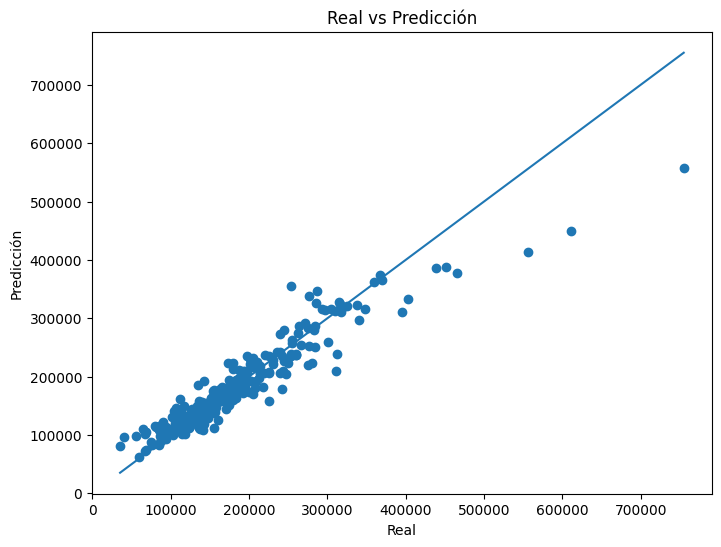

In [41]:
# Evaluacion: real vs prediccion (RF)
plt.figure(figsize=(8,6))

plt.scatter(y_test, rf_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

plt.xlabel("Real")
plt.ylabel("Predicción")
plt.title("Real vs Predicción")

plt.show()

In [42]:
# Evaluacion: validacion cruzada (RF)
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    rf_model,
    X,
    y,
    cv=5,
    scoring="r2"
)

print(scores)
print("Promedio:", scores.mean())

[0.87294035 0.83833947 0.87410798 0.88042502 0.80588849]
Promedio: 0.8543402602649375


# Evaluación del modelo

In [43]:
# Evaluacion: estabilidad del modelo (RF)
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    rf_model,
    X,
    y,
    cv=5,
    scoring="r2"
)

print(scores)
print("Promedio:", scores.mean())

# Analizar variación de los resultados
print("Desviación estándar:", scores.std())

# Evaluación del modelo
print("Train R²:", rf_model.score(X_train, y_train))
print("Test R²:", rf_model.score(X_test, y_test))

[0.87294035 0.83833947 0.87410798 0.88042502 0.80588849]
Promedio: 0.8543402602649375
Desviación estándar: 0.028357503334873253
Train R²: 0.9788900426966625
Test R²: 0.8872127821817596


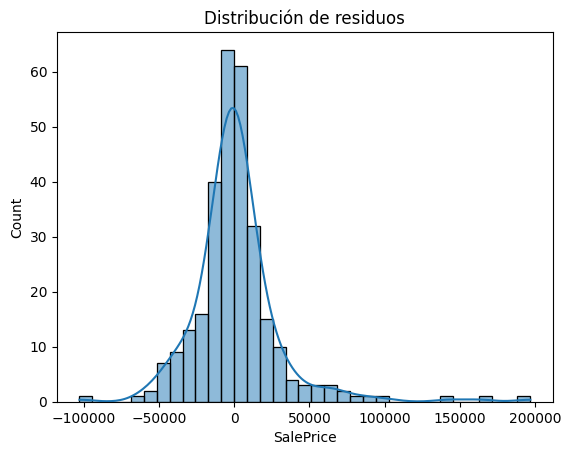

In [44]:
# Evaluacion: analizar residuos (RF)
residuos = y_test - rf_pred
sns.histplot(residuos, kde=True)
plt.title("Distribución de residuos")
plt.show()

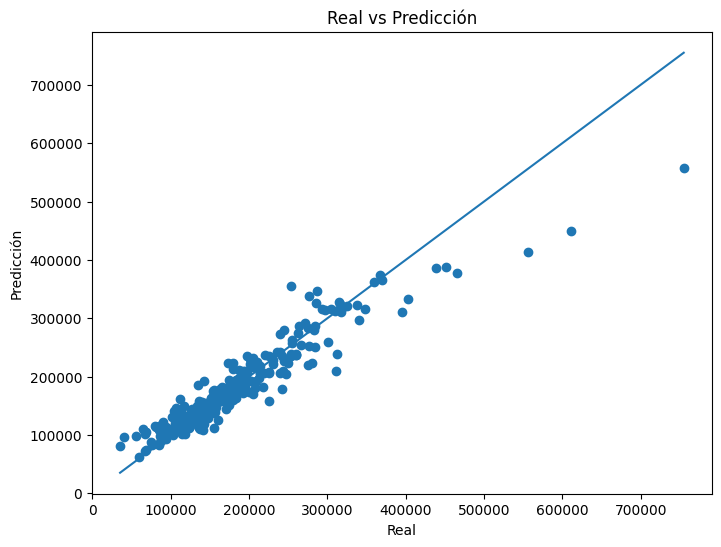

In [45]:
# Evaluacion: grafico real vs prediccion (RF)
plt.figure(figsize=(8,6))
plt.scatter(y_test, rf_pred)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)
plt.xlabel("Real")
plt.ylabel("Predicción")
plt.title("Real vs Predicción")
plt.show()

In [46]:
# Evaluacion: top 15 importancias (RF)
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance.head(15))

         Feature  Importance
4    OverallQual    0.559389
16     GrLivArea    0.121035
14      2ndFlrSF    0.035108
12   TotalBsmtSF    0.034127
9     BsmtFinSF1    0.029384
13      1stFlrSF    0.026776
3        LotArea    0.017382
27    GarageArea    0.015495
26    GarageCars    0.012695
6      YearBuilt    0.012543
2    LotFrontage    0.009219
25   GarageYrBlt    0.007731
23  TotRmsAbvGrd    0.007250
7   YearRemodAdd    0.006408
29   OpenPorchSF    0.006180
